In [261]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import itertools
import time
import multiprocessing as mp
import copyreg
import types

In [262]:
def mpPandasObj(func, pdObj, numThreads=24, mpBatches=1, linMols=True, **kargs):
    '''
    Parallelize jobs, return a DataFrame or Series
    + func: function to be parallelized. Returns a DataFrame
    + pdObj[0]: Name of argument used to pass the molecule
    + pdObj[1]: List of atoms that will be grouped into molecules
    + kargs: any other argument needed by func
    Example: df1=mpPandasObj(func,(’molecule’,df0.index),24,**kargs) 
    '''
    import pandas as pd
    if linMols:
        parts = linParts(len(pdObj[1]), numThreads * mpBatches)
    else:
        parts = nestedParts(len(pdObj[1]), numThreads * mpBatches)
    jobs = []
    for i in xrange(1, len(parts)):
        job = {pdObj[0]: pdObj[1][parts[i-1]:parts[i]], 'func': func}
        job.update(kargs)
        jobs.append(job)
    if numThreads == 1:
        out = processJobs_(jobs)
    else:
        out = processJobs(jobs, numThreads=numThreads)
    if isinstance(out[0], pd.DataFrame):
        df0 = pd.DataFrame()
    elif isinstance(out[0], pd.Series):
        df0 = pd.Series()
    else:
        return out
    for i in out:
        df0 = df0.append(i)
    return df0.sort_index()


def _pickle_method(method):
    func_name = method.im_func.__name__
    obj = method.im_self
    cls = method.im_class
    return _unpickle_method, (func_name, obj, cls)


def _unpickle_method(func_name, obj, cls):
    for cls in cls.mro():
        try:
            func = cls.__dict__[func_name]
        except KeyError:
            pass
        else:
            break
    return func.__get__(obj, cls)


import copyreg, types, multiprocessing as mp
copyreg.pickle(types.MethodType, _pickle_method, _unpickle_method)


def expandCall(kargs):
    # Expand the arguments of a callback function, kargs[’func’]
    func = kargs['func']
    del kargs['func']
    out = func(**kargs)
    return out


def reportProgress(jobNum, numJobs, time0, task):
    # Report progress as asynch jobs are completed
    msg = [float(jobNum) / numJobs, (time.time() - time0) / 60.]
    msg.append(msg[1] * (1 / msg[0] - 1))
    timeStamp = str(dt.datetime.fromtimestamp(time.time()))
    msg = timeStamp + ' ' + str(round(msg[0] * 100, 2)) + '% ' + task + ' done after ' + \
        str(round(msg[1], 2)) + ' minutes. Remaining ' + str(round(msg[2], 2)) + ' minutes.'
    if jobNum < numJobs:
        sys.stderr.write(msg + '\r')
    else:
        sys.stderr.write(msg + '\n')
    return


def processJobs(jobs, task=None, numThreads=24):
    # Run in parallel.
    # jobs must contain a ’func’ callback, for expandCall
    if task is None:
        task = jobs[0]['func'].__name__
    pool = mp.Pool(processes=numThreads)
    outputs, out, time0 = pool.imap_unordered(expandCall, jobs), [], time.time()  # Process asynchronous output, report progress
    for i, out_ in enumerate(outputs, 1):
        out.append(out_)
        reportProgress(i, len(jobs), time0, task)
    pool.close()
    pool.join()  # this is needed to prevent memory leaks
    return out


def processJobs_(jobs):
    # Run jobs sequentially, for debugging
    out = []
    for job in jobs:
        out_ = expandCall(job)
        out.append(out_)
    return out


def nestedParts(numAtoms, numThreads, upperTriang=False):  # partition of atoms with an inner loop
    parts, numThreads_ = [0], min(numThreads, numAtoms)
    for num in range(numThreads_):
        part = 1 + 4 * (parts[-1]**2 + parts[-1] + numAtoms * (numAtoms + 1.) / numThreads_)
        part = (-1 + part**.5) / 2.
        parts.append(part)
    parts = np.round(parts).astype(int)
    if upperTriang:  # the first rows are the heaviest
        parts = np.cumsum(np.diff(parts)[::-1])
        parts = np.append(np.array([0]), parts)
    return parts


def linParts(numAtoms, numThreads):
    # partition of atoms with a single loop
    parts = np.linspace(0, numAtoms, min(numThreads, numAtoms) + 1)
    parts = np.ceil(parts).astype(int)
    return parts


In [263]:
# DATA DOWNLOAD

# VOLUME BARS AND INFORMATION DRIVEN BARS NEED TO BE ADDED

def download_data(tickers, start_date, end_date, interval='1d'):
    data_dict = {}  # Dictionary to store data for each ticker
    
    for ticker in tickers:
        ticker_obj = yf.Ticker(ticker)
        data = ticker_obj.history(start=start_date, end=end_date, interval=interval)
        data_dict[ticker] = data  # Store data in dictionary with ticker as key
    
    return data_dict


# DATA DOWNLOAD

# VOLUME BARS AND INFORMATION DRIVEN BARS NEED TO BE ADDED

def download_data(tickers, start_date, end_date, interval='1d'):
    data_dict = {}  # Dictionary to store data for each ticker
    
    for ticker in tickers:
        ticker_obj = yf.Ticker(ticker)
        data = ticker_obj.history(start=start_date, end=end_date, interval=interval)
        data_dict[ticker] = data  # Store data in dictionary with ticker as key
    
    return data_dict

def convert_to_single_dataframe(data_dict):
    # Concatenate all the dataframes into a single dataframe with a MultiIndex
    combined_data = pd.concat(data_dict.values(), keys=data_dict.keys(), names=['Ticker', 'Date'])
    
    # Reset index to bring 'Ticker' and 'Date' into columns
    combined_data = combined_data.reset_index()


    combined_data['Date'] = pd.to_datetime(combined_data['Date'], utc=True).dt.tz_convert(None)
    # Set 'Date' as the index
    combined_data.set_index('Date', inplace=True)

    return combined_data

# Example usage:
tickers = ['AAPL']
data_dict = download_data(tickers, '2016-1-1', '2023-10-29', interval='1d')
df = convert_to_single_dataframe(data_dict)

df




,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2016-01-04 05:00:00,AAPL,23.384623,24.013623,23.245605,24.009064,270597600,0.0,0.0
2016-01-05 05:00:00,AAPL,24.100230,24.123019,23.339051,23.407419,223164000,0.0,0.0
2016-01-06 05:00:00,AAPL,22.917431,23.329928,22.760183,22.949337,273829600,0.0,0.0
2016-01-07 05:00:00,AAPL,22.488986,22.819437,21.976215,21.980772,324377600,0.0,0.0
2016-01-08 05:00:00,AAPL,22.459359,22.586981,22.051421,22.097000,283192000,0.0,0.0
...,...,...,...,...,...,...,...,...
2023-10-23 04:00:00,AAPL,170.910004,174.009995,169.929993,173.000000,55980100,0.0,0.0
2023-10-24 04:00:00,AAPL,173.050003,173.669998,171.449997,173.440002,43816600,0.0,0.0
2023-10-25 04:00:00,AAPL,171.880005,173.059998,170.649994,171.100006,57157000,0.0,0.0


In [264]:
# SYMMETRIC CUSUM FILTER

# Takes raw data as input and returns signifcant events, which will be used to fit the model on optimal moments

def getTEvents(graw,h):
    tEvents, sPos, Sneg = [], 0, 0
    diff = graw.diff()
    for i in diff.index[1:]:
        sPos, Sneg = max(0, sPos+diff.loc[i]), min(0, Sneg+diff.loc[i])
        if Sneg<-h:
            Sneg=0; tEvents.append(i)
        elif sPos>h:
            sPos=0; tEvents.append(i)
    return pd.DatetimeIndex(tEvents)


def getDailyVol(close, span0=100):
    """
    Compute daily volatility adjusted for auto-correlation

    Args:
    close (pd.Series): Closing prices
    span0 (int): Span parameter for Exponential Weighted Moving Average (EWMA)

    Returns:
    pd.Series: Daily volatility, reindexed to match the original close series
    """
    # Find the timestamp of the previous trading day for each trading day
    df0 = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    df0 = df0[df0 > 0]
    df0 = pd.Series(close.index[df0 - 1], index=close.index[close.shape[0] - df0.shape[0]:])

    # Compute daily returns
    df0 = close.loc[df0.index] / close.loc[df0.values].values - 1 

    # Apply Exponential Weighted Moving Standard Deviation
    df0 = df0.ewm(span=span0).std()

    return df0



In [265]:
# Triple Barrier Method

# Takes raw data and significant events as input and returns the timestamps for the upper and lower barriers. This incorporates meta-labeling

def applyPtSlOnT1(close,events,ptSl,molecule):
    """
    Args:
    close (pd.Series): Closing prices
    events (pd.DataFrame): DataFrame containing the events data
    ptSl (list): A list of two non-negative float values representing the profit-taking and stop-loss thresholds
    molecule (Index): An Index of event timestamps which will be processed by a single thread
    
    Returns:
    out (pd.DataFrame): DataFrame containing the timestamps at which each event hits its stop-loss or profit-taking barrier
    """
    events_=events.loc[molecule]
    out=events_[['t1']].copy(deep=True)
    if ptSl[0]>0:
        pt=ptSl[0]*events_['trgt']
    else:
        pt=pd.Series(index=events.index) # NaNs
    if ptSl[1]>0:
        sl=-ptSl[1]*events_['trgt']
    else:
        sl=pd.Series(index=events.index) # NaNs
    for loc,t1 in events_['t1'].fillna(close.index[-1]).iteritems():
        df0=close[loc:t1] # path prices
        df0=(df0/close[loc]-1)*events_.at[loc,'side'] # path returns
        out.loc[loc,'sl']=df0[df0<sl[loc]].index.min() # earliest stop loss.
        out.loc[loc,'pt']=df0[df0>pt[loc]].index.min() # earliest profit taking.
    return out


def getEvents(close,tEvents,ptsl, trgt, minRet, numThreads, t1=False,side=None):

        
    #1) get target
    trgt=trgt.loc[tEvents]
    trgt=trgt[trgt>minRet] # minRet
    #2) get t1 (max holding period)
    if t1 is False: t1=pd.Series(pd.NaT, index=tEvents)
    #3) form events object, apply stop loss on t1
    if side is None: side_,ptsl_=pd.Series(1.,index=trgt.index), [ptsl[0],ptsl[0]]
    else: side_,ptsl_=side.loc[trgt.index],ptsl[:2]
    events=pd.concat({'t1':t1,'trgt':trgt,'side':side_}, axis=1).dropna(subset=['trgt'])
    df0=mpPandasObj(func=applyPtSlOnT1,pdObj=('molecule',events.index),numThreads=numThreads,close=['Close'],events=events,ptSl=ptsl_)
    events['t1']=df0.dropna(how='all').min(axis=1) #pd.min ignores nan
    if side is None: events=events.drop('side',axis=1)
    return events


def getBins(events, close):
    '''
    Compute event's outcome (including side information, if provided).
    events is a DataFrame where:
    —events.index is event's starttime
    —events[’t1’] is event's endtime
    —events[’trgt’] is event's target
    —events[’side’] (optional) implies the algo's position side
    Case 1: ('side' not in events): bin in (-1,1) <-label by price action
    Case 2: ('side' in events): bin in (0,1) <-label by pnl (meta-labeling)
    '''


    """
    Args:
    events (pd.DataFrame): DataFrame containing the events data
    close (pd.Series): Closing prices
    
    Returns:
    out (pd.DataFrame): DataFrame containing the returns and binary labels for each event
    """
    
    #1) prices aligned with events
    events_=events.dropna(subset=['t1'])
    px=events_.index.union(events_['t1'].values).drop_duplicates()
    px=close.reindex(px,method='bfill')
    #2) create out object
    out=pd.DataFrame(index=events_.index)
    out['ret']=px.loc[events_['t1'].values].values/px.loc[events_.index]-1
    if 'side' in events_: out['ret']*=events_['side'] # meta-labeling
    out['bin']=np.sign(out['ret'])
    if 'side' in events_: out.loc[out['ret']<=0,'bin']=0 # meta-labeling
    return out

    

In [266]:
# # Sample importance NOT DONE

# def mpNumCoEvents(closeIdx, t1, molecule):
#     """
#     Compute the number of concurrent events per bar.
#     + molecule[0] is the date of the first event on which the weight will be computed
#     + molecule[-1] is the date of the last event on which the weight will be computed
#     Any event that starts before t1[molecule].max() impacts the count.
#     """
#     # 1) find events that span the period [molecule[0], molecule[-1]]
#     t1 = t1.fillna(closeIdx[-1])  # unclosed events still must impact other weights
#     t1 = t1[t1 >= molecule[0]]  # events that end at or after molecule[0]
#     t1 = t1.loc[:t1[molecule].max()]  # events that start at or before t1[molecule].max()

#     # 2) count events spanning a bar
#     iloc = closeIdx.searchsorted(np.array([t1.index[0], t1.max()]))
#     count = pd.Series(0, index=closeIdx[iloc[0]:iloc[1]+1])

#     for tIn, tOut in t1.iteritems():
#         count.loc[tIn:tOut] += 1
#     return count.loc[molecule[0]:t1[molecule].max()]

# def mpSampleTW(t1, numCoEvents, molecule):
#     """
#     Derive average uniqueness over the event's lifespan.
#     + The average uniqueness of an event is the probability that a random sample
#     of the population is not picked as a co-event.
#     This is the probability of an event not being duplicated in the whole sample,
#     aka the inverse of the product of random sampling:
#     1 - P(E1 n E2 n ... n En)
#     + Average uniqueness accounts for the fact that large events (many counts) should
#     be penalized in terms of average uniqueness because they are more likely to be
#     drawn twice in a random sample.
#     """
#     wght = pd.Series(index=molecule)
#     for tIn, tOut in t1.loc[wght.index].iteritems():
#         wght.loc[tIn] = (1. / numCoEvents.loc[tIn:tOut]).mean()
#     return wght
# #———————————————————————————————————————
# numCoEvents=mpPandasObj(mpNumCoEvents,('molecule',events.index),numThreads, \ closeIdx=close.index,t1=events['t1'])
# numCoEvents=numCoEvents.loc[~numCoEvents.index.duplicated(keep='last')] numCoEvents=numCoEvents.reindex(close.index).fillna(0) out['tW']=mpPandasObj(mpSampleTW,('molecule',events.index),numThreads, \
# t1=events['t1'],numCoEvents=numCoEvents)



In [267]:
# FRACTIONAL DIFFERENCING FEATURES

def getWeights_EW(d,size):
    # thres>0 drops insignificant weights
    w=[1.]
    for k in range(1,size):
        w_=-w[-1]/k*(d-k+1)
        w.append(w_)
    w=np.array(w[::-1]).reshape(-1,1)
    return w

def fracDiff_FW(series,d,thres=1e-5):
    '''
    Increasing width window, with treatment of NaNs
    Note 1 : For thres=1e-5, approx 50% of the weights are zero
    Note 2 : d can be any positive fractional, not necessarily bounded [0,1].
    '''
    #1) Compute weights for the longest series
    w=getWeights_EW(d,series.shape[0])
    #2) Determine initial calcs to be skipped based on weight-loss threshold
    w_=np.cumsum(abs(w))
    w_/=w_[-1]
    skip=w_[w_>thres].shape[0]
    #3) Apply weights to values
    df={}
    for name in series.columns:
        seriesF,df_=series[[name]].fillna(method='ffill').dropna(),pd.Series()
        for iloc in range(skip,seriesF.shape[0]):
            loc=seriesF.index[iloc]
            if not np.isfinite(series.loc[loc,name]): continue # exclude NAs
            df_[loc]=np.dot(w[-(iloc+1):,:].T,seriesF.loc[:loc])[0,0]
        df[name]=df_.copy(deep=True)
    df=pd.concat(df,axis=1)
    return df

def getWeights_FFD(d,thres):
    w,k = [1.], 1
    while True:
        w_ = -w[-1]/k*(d-k+1)
        if abs(w_)<thres: break
        w.append(w_); k+=1
    return np.array(w[::-1]).reshape(-1,1)

def fracDiff_FFD(series,d,thres=1e-5):
    #constant width window (new solution)
    w,width = getWeights_FFD(d,thres), len(getWeights_FFD(d,thres))
    for name in series.columns:
        seriesF,df = series[[name]].fillna(method='ffill').dropna(), pd.Series()
        for iloc1 in range(width,seriesF.shape[0]):
            loc0,loc1 = seriesF.index[iloc1-width], seriesF.index[iloc1]
            if not np.isfinite(series.loc[loc1,name]): continue
            df[loc1] = np.dot(w.T,seriesF.loc[loc0:loc1])[0,0]
        df[name] = df.copy(deep=True)
    df = pd.concat(df,axis=1)
    return df


def plotMinFFD(df0, feature='Close'):
    out = pd.DataFrame(columns=['adfStat', 'pVal', 'lags', 'nObs', '95% conf', 'corr'])
    for d in np.linspace(0, 1, 11):
        df1 = np.log(df0[[feature]]).resample('1D').last()
        df2 = fracDiff_FFD(df1, d, thres=1e-5)
        corr = np.corrcoef(df1.loc[df2.index, feature], df2[feature])[0, 1]
        df2 = adfuller(df2[feature], maxlag=1, regression='c', autolag=None)
        out.loc[d] = list(df2[:4]) + [df2[4]['5%']] + [corr]
    out[['adfStat', 'corr']].plot(secondary_y='adfStat')
    plt.axhline(out['95% conf'].mean(), linewidth=1, color='r', linestyle='dotted')
    plt.show()  # This will show the plot in your environment
    return out  # Optionally return the DataFrame `out` for further analysis or usage outside the function




In [268]:
# PURGED K FOLD CROSS VALIDATION & EMBARGO

def getTrainTimes(t1,testTimes):
    '''
    t1.index: Time when the observation started
    t1.value: Time when the observation ended
    testTimes: A pandas Series with the test start and end times
    
    Returns:
    trn: A pandas Series with the train start and end times
    '''
    trn=t1.copy(deep=True)
    for i,j in testTimes.iteritems():
        df0=trn[(i<=trn.index)&(trn.index<=j)].index # train starts within test
        df1=trn[(i<=trn)&(trn<=j)].index # train ends within test
        df2=trn[(trn.index<=i)&(j<=trn)].index # train envelops test
        trn=trn.drop(df0.union(df1).union(df2))
    return trn

def getEmbargoTimes(times,pctEmbargo):
    '''
    times.index: Time when the observation started
    times.value: Time when the observation ended
    pctEmbargo: Percentage of embargo on train data
    
    Returns:
    embargos: A pandas Series with the embargo start and end times
    '''
    step=int(times.shape[0]*pctEmbargo)
    if step==0:
        mbrg=pd.Series(times,index=times)
    else:
        mbrg=pd.Series(times[step:],index=times[:-step])
        mbrg=mbrg.append(pd.Series(times[-1],index=times[-step:]))
    return mbrg

class PurgedKFold():
    '''
    Extend KFold class to work with labels that span intervals
    The train is purged of observations overlapping test-label intervals
    Test set is assumed contiguous (shuffle=False), w/o training samples in between
    '''
    def __init__(self,n_splits=3,t1=None,pctEmbargo=0.):
        if not isinstance(t1,pd.Series):
            raise ValueError('Label Through Dates must be a pd.Series')
        super(PurgedKFold,self).__init__(n_splits,shuffle=False,random_state=None)
        self.t1=t1
        self.pctEmbargo=pctEmbargo
    def split(self,X,y=None,groups=None):
        if (X.index==self.t1.index).sum()!=len(self.t1):
            raise ValueError('X and ThruDateValues must have the same index')
        indices=np.arange(X.shape[0])
        mbrg=int(X.shape[0]*self.pctEmbargo)
        test_starts=[(i[0],i[-1]+1) for i in np.array_split(np.arange(X.shape[0]),self.n_splits)]
        for i,j in test_starts:
            t0=self.t1.index[i] # start of test set
            test_indices=indices[i:j]
            maxT1Idx=self.t1.index.searchsorted(self.t1[test_indices].max())
            train_indices=self.t1.index.searchsorted(self.t1[self.t1<=t0].index)
            if maxT1Idx<X.shape[0]: # right train (with embargo)
                train_indices=np.concatenate((train_indices,indices[maxT1Idx+mbrg:]))
            yield train_indices,test_indices

def cvScore(clf,X,y,sample_weight,scoring='neg_log_loss',t1=None,cv=None,cvGen=None,pctEmbargo=None):
    '''
    clf: Classifier
    X: Features
    y: Labels
    sample_weight: Sample weights
    scoring: Scoring function
    t1: Vertical barrier thresholds
    cv: Number of cross-validation folds
    cvGen: Cross-validation generator
    pctEmbargo: Percentage of embargo
    
    Returns:
    score: Score of the classifier
    '''
    if scoring not in ['neg_log_loss','accuracy']:
        raise Exception('wrong scoring method.')
    from sklearn.metrics import log_loss,accuracy_score
    if cvGen is None:
        cvGen=PurgedKFold(n_splits=cv,t1=t1,pctEmbargo=pctEmbargo) # purged
    score=[]
    for train,test in cvGen.split(X=X):
        fit=clf.fit(X=X.iloc[train,:],y=y.iloc[train],sample_weight=sample_weight.iloc[train].values)
        if scoring=='neg_log_loss':
            prob=fit.predict_proba(X.iloc[test,:])
            score_=-log_loss(y.iloc[test],prob,sample_weight=sample_weight.iloc[test].values,labels=clf.classes_)
        else:
            pred=fit.predict(X.iloc[test,:])
            score_=accuracy_score(y.iloc[test],pred,sample_weight=sample_weight.iloc[test].values)
        score.append(score_)
    return np.array(score)






In [269]:
# FEATURE IMPORTANCE

def featImpMDA(clf, X, y, cv, sample_weight, t1, pctEmbargo, scoring='neg_log_loss'):
    # feat importance based on OOS score reduction
    if scoring not in ['neg_log_loss', 'accuracy']:
        raise Exception('wrong scoring method.')

    from sklearn.metrics import log_loss, accuracy_score
    cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)  # purged cv
    scr0, scr1 = pd.Series(), pd.DataFrame(columns=X.columns)

    for i, (train, test) in enumerate(cvGen.split(X=X)):
        X0, y0, w0 = X.iloc[train, :], y.iloc[train], sample_weight.iloc[train]
        X1, y1, w1 = X.iloc[test, :], y.iloc[test], sample_weight.iloc[test]
        fit = clf.fit(X=X0, y=y0, sample_weight=w0.values)

        if scoring == 'neg_log_loss':
            prob = fit.predict_proba(X1)
            scr0.loc[i] = -log_loss(y1, prob, sample_weight=w1.values, labels=clf.classes_)
        else:
            pred = fit.predict(X1)
            scr0.loc[i] = accuracy_score(y1, pred, sample_weight=w1.values)

        for j in X.columns:
            X1_ = X1.copy(deep=True)
            np.random.shuffle(X1_[j].values)  # permutation of a single column

            if scoring == 'neg_log_loss':
                prob = fit.predict_proba(X1_)
                scr1.loc[i, j] = -log_loss(y1, prob, sample_weight=w1.values, labels=clf.classes_)
            else:
                pred = fit.predict(X1_)
                scr1.loc[i, j] = accuracy_score(y1, pred, sample_weight=w1.values)

    imp = (-scr1).add(scr0, axis=0)

    if scoring == 'neg_log_loss':
        imp = imp / -scr1
    else:
        imp = imp / (1. - scr1)

    imp = pd.concat({'mean': imp.mean(), 'std': imp.std() * imp.shape[0]**-.5}, axis=1)
    return imp, scr0.mean()


def auxFeatImpSFI(featNames, clf, trnsX, cont, scoring, cvGen):
    imp = pd.DataFrame(columns=['mean', 'std'])
    for featName in featNames:
        df0 = cvScore(clf, X=trnsX[[featName]], y=cont['bin'], sample_weight=cont['w'], scoring=scoring, cvGen=cvGen)
        imp.loc[featName, 'mean'] = -df0.mean()
        imp.loc[featName, 'std'] = df0.std() * df0.shape[0]**-.5
    return imp

def get_eVec(dot,varThres):
    # Compute eVec from dot prod matrix, reduce dimension
    eVal,eVec=np.linalg.eigh(dot)
    idx=eVal.argsort()[::-1] # arguments for sorting eVal desc
    eVal,eVec=eVal[idx],eVec[:,idx]
    #2) only positive eVals
    eVal=pd.Series(eVal,index=['PC_'+str(i+1) for i in range(eVal.shape[0])])
    eVec=pd.DataFrame(eVec,index=dot.index,columns=eVal.index)
    eVec=eVec.loc[:,eVal.index]
    #3) reduce dimension, form PCs
    cumVar=eVal.cumsum()/eVal.sum()
    dim=cumVar.values.searchsorted(varThres)
    eVal,eVec=eVal.iloc[:dim+1],eVec.iloc[:,:dim+1]
    return eVal,eVec

def orthoFeats(dfX,varThres=.95):
    # Given a DataFrame dfX of features, compute orthofeatures dfP
    dfZ=dfX.sub(dfX.mean(),axis=1).div(dfX.std(),axis=1) # standardize
    dot=pd.DataFrame(np.dot(dfZ.T,dfZ)/dfZ.shape[0],index=dfX.columns,columns=dfX.columns)
    eVal,eVec=get_eVec(dot,varThres)
    dfP=np.dot(dfZ,eVec)
    return dfP

def featImportance(trnsX,cont,n_estimators=1000,cv=10,max_samples=1.,numThreads=24, pctEmbargo=0,scoring='accuracy',method='SFI',minWLeaf=0.,**kargs):
    # feature importance from a random forest
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import BaggingClassifier
    from mpEngine import mpPandasObj
    n_jobs=(-1 if numThreads>1 else 1) 
    # run 1 thread with ht_helper in dirac1 #1) prepare classifier,cv. max_features=1, to prevent masking
    clf=DecisionTreeClassifier(criterion='entropy',max_features=1,
    class_weight='balanced',min_weight_fraction_leaf=minWLeaf) 
    clf=BaggingClassifier(base_estimator=clf,n_estimators=n_estimators,
    max_features=1.,max_samples=max_samples,oob_score=True,n_jobs=n_jobs)
    fit=clf.fit(X=trnsX,y=cont['bin'],sample_weight=cont['w'].values) 
    oob=fit.oob_score_
    if method=='MDA':
        imp,oos=featImpMDA(clf,X=trnsX,y=cont['bin'],cv=cv,sample_weight=cont['w'], t1=cont['t1'],pctEmbargo=pctEmbargo,scoring=scoring)
    elif method=='SFI': 
        cvGen=PurgedKFold(n_splits=cv,t1=cont['t1'],pctEmbargo=pctEmbargo) 
        oos=cvScore(clf,X=trnsX,y=cont['bin'],sample_weight=cont['w'],scoring=scoring,
    cvGen=cvGen).mean()
    clf.n_jobs=1 # paralellize auxFeatImpSFI rather than clf 
    imp=mpPandasObj(auxFeatImpSFI,('featNames',trnsX.columns),numThreads,
    clf=clf,trnsX=trnsX,cont=cont,scoring=scoring,cvGen=cvGen) 
    return imp,oob,oos


def plotFeatImportance(pathOut, imp, oob, oos, method, tag=0, simNum=0, **kargs):
    # plot mean imp bars with std
    plt.figure(figsize=(10, imp.shape[0] / 5.))
    imp = imp.sort_values('mean', ascending=True)
    ax = imp['mean'].plot(kind='barh', color='b', alpha=.25, xerr=imp['std'], error_kw={'ecolor': 'r'})

    if method == 'MDI':
        plt.xlim([0, imp.sum(axis=1).max()])
        plt.axvline(1. / imp.shape[0], linewidth=1, color='r', linestyle='dotted')
    else:
        plt.xlim([imp['mean'].min() - imp['std'].max(), imp['mean'].max() + imp['std'].max()])

    ax.get_yaxis().set_visible(False)
    for i, j in zip(ax.patches, imp.index):
        ax.text(i.get_width() / 2, i.get_y() + i.get_height() / 2, j, ha='center', va='center', color='black')

    plt.title(f'tag={tag} | simNum={simNum} | oob={round(oob, 4)} | oos={round(oos, 4)}')
    plt.savefig(f'{pathOut}featImportance_{simNum}.png', dpi=100)
    plt.clf()
    plt.close()

    return


In [270]:
#Hparams Tuning



In [271]:
# BET SIZING

def betSize(w, x):
    return x * (w + x**2)**-0.5

def getTPos(w, f, mP, maxPos):
    return int(betSize(w, f - mP) * maxPos)

def invPrice(f, w, m):
    return f - m * (w / (1 - m**2))**0.5

def limitPrice(tPos, pos, f, w, maxPos):
    sgn = (1 if tPos >= pos else -1)
    lP = 0
    for j in range(abs(pos + sgn), abs(tPos + 1)):
        lP += invPrice(f, w, j / float(maxPos))
    lP /= tPos - pos
    return lP

def getW(x, m):
    # 0 < alpha < 1
    return x**2 * (m**-2 - 1)

def main():
    pos, maxPos, mP, f, wParams = 0, 100, 100, 115, {'divergence': 10, 'm': 0.95}
    w = getW(wParams['divergence'], wParams['m'])  # calibrate w
    tPos = getTPos(w, f, mP, maxPos)  # get tPos
    lP = limitPrice(tPos, pos, f, w, maxPos)  # limit price for order
    return

if __name__ == '__main__':
    main()


In [272]:
# BACKTEST

#  CPCV ALGORITHM , may be faulty

def cpcvImplementation(X, y, clf, num_folds, k, scoring):
    T = X.shape[0]
    groups = np.array_split(range(T), num_folds)
    combinations = itertools.combinations(range(num_folds), k)
    scores = []

    for testing_groups in combinations:
        training_groups = set(range(num_folds)) - set(testing_groups)
        training_indices = np.hstack([groups[i] for i in training_groups])
        testing_indices = np.hstack([groups[i] for i in testing_groups])

        t1_train = t1.iloc[training_indices]
        cvGen = PurgedKFold(n_splits=len(training_groups), t1=t1_train, pctEmbargo=0.01)  # Adjust pctEmbargo as needed

        # Purge and Embargo
        train_indices_purged, _ = next(cvGen.split(X.iloc[training_indices]))
        
        # Fit and Score
        clf.fit(X.iloc[train_indices_purged], y.iloc[train_indices_purged])
        score = clf.score(X.iloc[testing_indices], y.iloc[testing_indices])  # Change to custom scoring if needed
        scores.append(score)

    return np.mean(scores), np.std(scores)


def calculate_metrics(predictions, prices, risk_free_rate=0.0):
    """
    Calculate Sharpe Ratio, Returns, and Maximum Drawdown.
    predictions: Model predictions corresponding to market positions (1, -1, or 0)
    prices: Actual market prices (used to calculate returns)
    risk_free_rate: Risk-free rate for Sharpe Ratio calculation
    """
    # Convert predictions to market positions and calculate daily returns
    positions = predictions.shift(1)  # Shift positions to avoid look-ahead bias
    daily_returns = positions * (prices.pct_change())

    # Calculate cumulative returns
    cumulative_returns = (1 + daily_returns).cumprod()

    # Calculate maximum drawdown
    rolling_max = cumulative_returns.cummax()
    drawdowns = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdowns.min()

    # Calculate Sharpe Ratio
    excess_returns = daily_returns - risk_free_rate / 252
    sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(252)

    return {
        'cumulative_returns': cumulative_returns[-1],
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio
    }



In [273]:
############################################################################################################################################################################

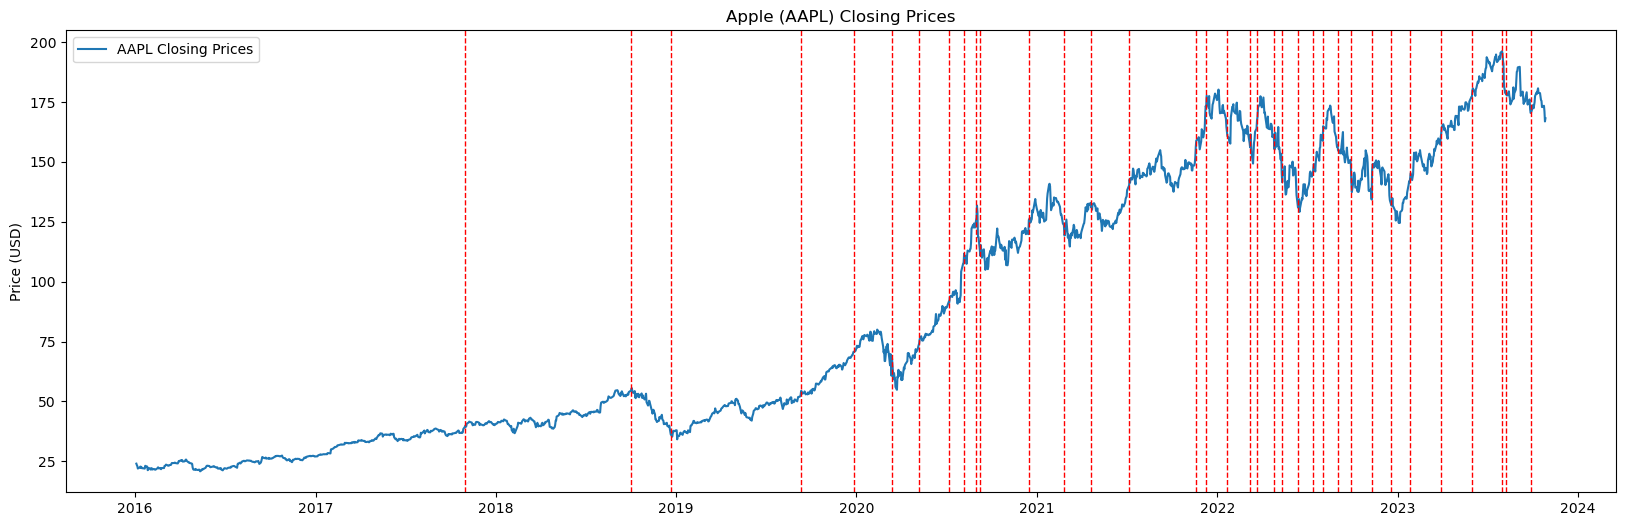

In [274]:
cusum_events = getTEvents(df['Close'], h=18)

# Assuming 'df' is your DataFrame with the data
closing_prices = df[df['Ticker'] == 'AAPL']['Close']

plt.figure(figsize=(20, 6))

# Convert the index back to DateTimeIndex
closing_prices.index = pd.to_datetime(closing_prices.index)

# Assuming 'cusum_events' is a list of strings representing dates
# Convert 'cusum_events' to DateTimeIndex as well
cusum_events = pd.to_datetime(cusum_events)


plt.plot(closing_prices, label='AAPL Closing Prices')
plt.title('Apple (AAPL) Closing Prices')
for event in cusum_events:
    plt.axvline(x=event, color='red', linestyle='--', linewidth=1)

# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
# plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(False)
plt.show()



In [275]:
daily_vol = getDailyVol(df['Close'], span0=100)
